# Questao 2

Derivacao da resposta ao impulso ideal para as tres respostas de modulo da
figura e projeto dos correspondentes filtros FIR para `M in {50, 100}`.

Para o item **2(b)**, o enunciado mostra a forma da resposta em funcao de
`omega_c`, mas nao fixa um valor numerico. Aqui a derivacao permanece
simbolica e, para os graficos numericos, foi adotado o valor normalizado
`omega_c = pi / 8`, de modo que o suporte do triangulo fique em
`[-pi/4, pi/4]`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
for candidate in [CWD, *CWD.parents]:
    helper_path = candidate / 'pratica_7' / 'fir_utils.py'
    if helper_path.exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError('Nao foi possivel localizar pratica_7/fir_utils.py a partir do diretorio atual.')

PRACTICE_DIR = REPO_ROOT / 'pratica_7'
DATA_DIR = REPO_ROOT / 'data'
if str(PRACTICE_DIR) not in sys.path:
    sys.path.insert(0, str(PRACTICE_DIR))

from fir_utils import (
    apply_window,
    display_rows,
    plot_frequency_grid,
    plot_impulse_grid,
    plot_pole_zero_grid,
    q2a_ideal,
    q2a_magnitude,
    q2b_ideal,
    q2b_magnitude,
    q2c_ideal,
    q2c_magnitude,
    summarize_error_bank,
)

ORDERS = [50, 100]
WINDOWS = ['retangular', 'triangular', 'hamming', 'hann', 'blackman']
OMEGA_C = np.pi / 8.0


As respostas ao impulso ideais, centradas em `n = 0`, ficam:

**(a)** Dois patamares em modulo:

\[
H_d(\omega) =
\begin{cases}
2, & |\omega| \le \pi/6 \\
1, & \pi/6 < |\omega| \le \pi/3 \\
0, & \pi/3 < |\omega| \le \pi
\end{cases}
\]

\[
h_d[n] =
\begin{cases}
1/2, & n = 0 \\
\dfrac{\sin(\pi n / 6) + \sin(\pi n / 3)}{\pi n}, & n \ne 0
\end{cases}
\]

**(b)** Triangulo simetrico:

\[
H_d(\omega) =
\begin{cases}
1 - |\omega|/(2\omega_c), & |\omega| \le 2\omega_c \\
0, & |\omega| > 2\omega_c
\end{cases}
\]

\[
h_d[n] =
\begin{cases}
\omega_c / \pi, & n = 0 \\
\dfrac{\sin^2(\omega_c n)}{\pi \omega_c n^2}, & n \ne 0
\end{cases}
\]

**(c)** Rampa ate `pi/4` e patamar ate `pi/2`:

\[
H_d(\omega) =
\begin{cases}
4|\omega|/\pi, & |\omega| \le \pi/4 \\
1, & \pi/4 < |\omega| \le \pi/2 \\
0, & |\omega| > \pi/2
\end{cases}
\]

\[
h_d[n] =
\begin{cases}
3/8, & n = 0 \\
\dfrac{\sin(\pi n/2)}{\pi n}
+ \dfrac{4(\cos(\pi n/4) - 1)}{\pi^2 n^2}, & n \ne 0
\end{cases}
\]


2(a) Resposta em dois patamares


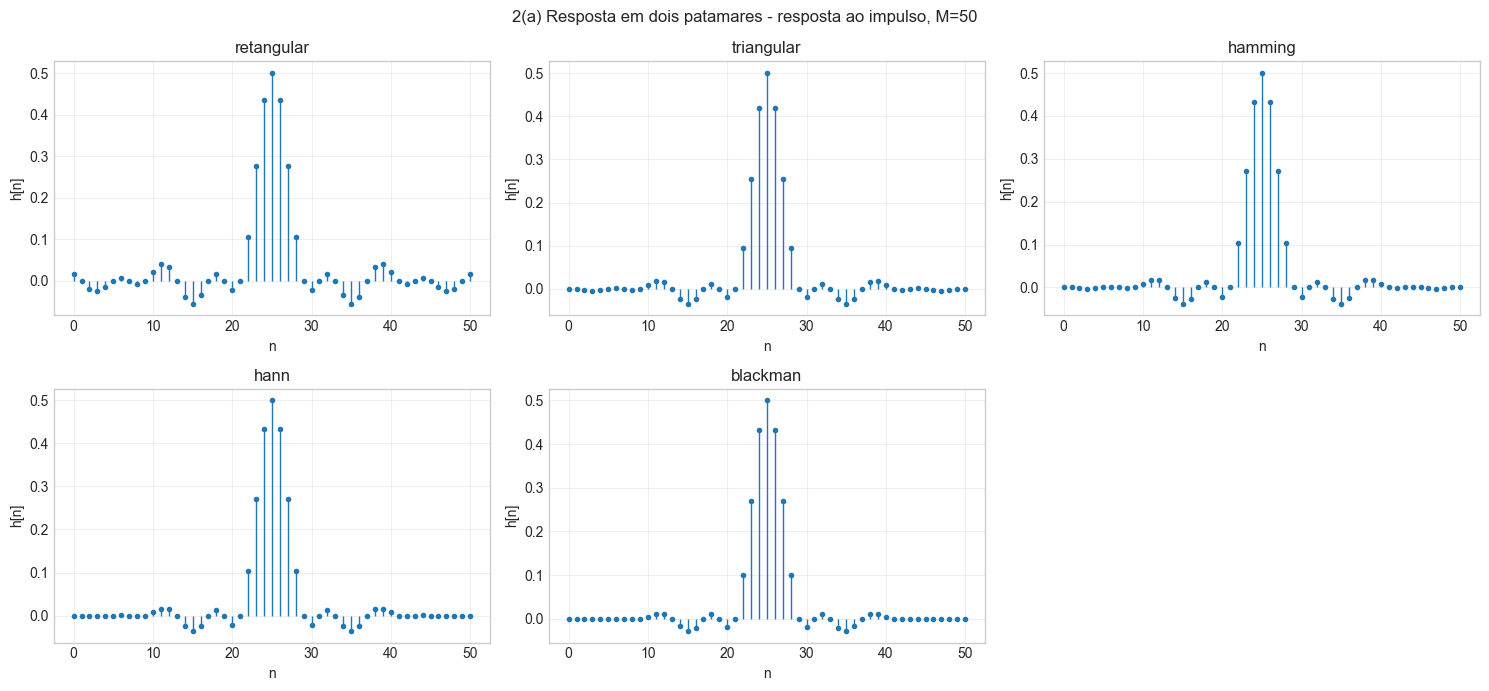

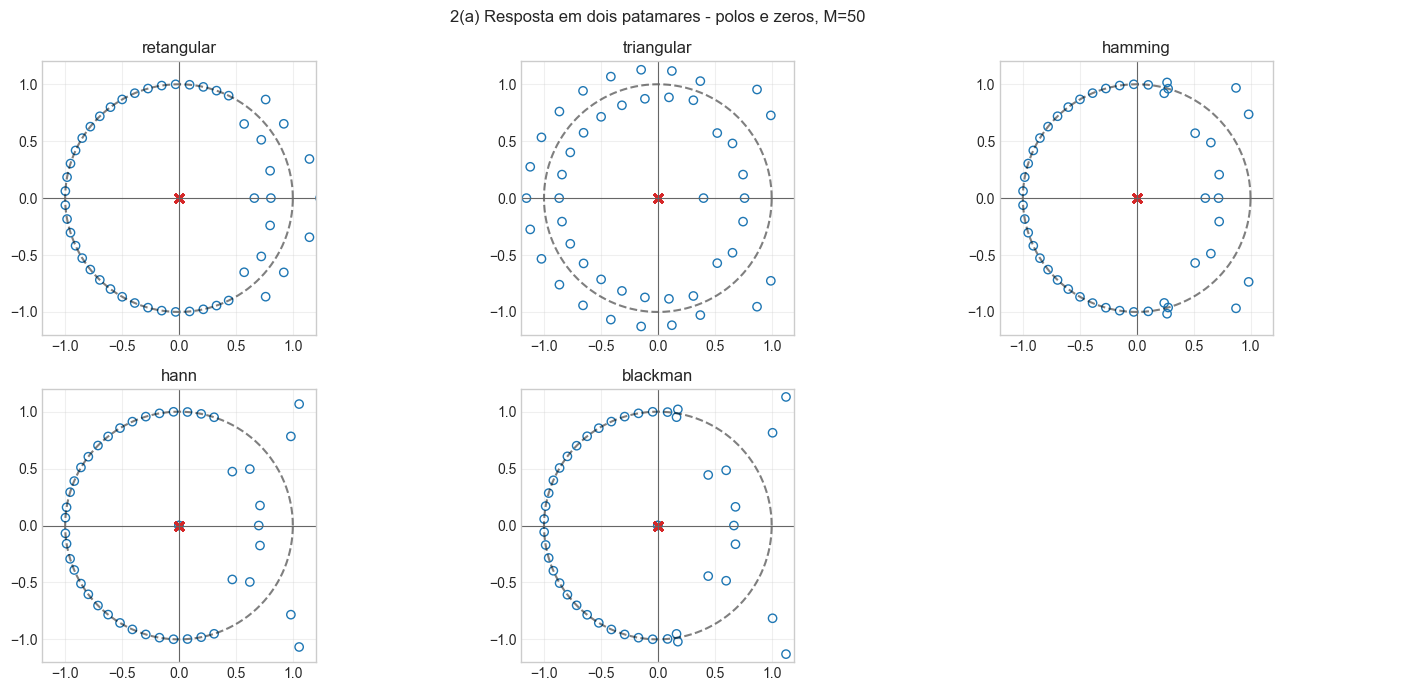

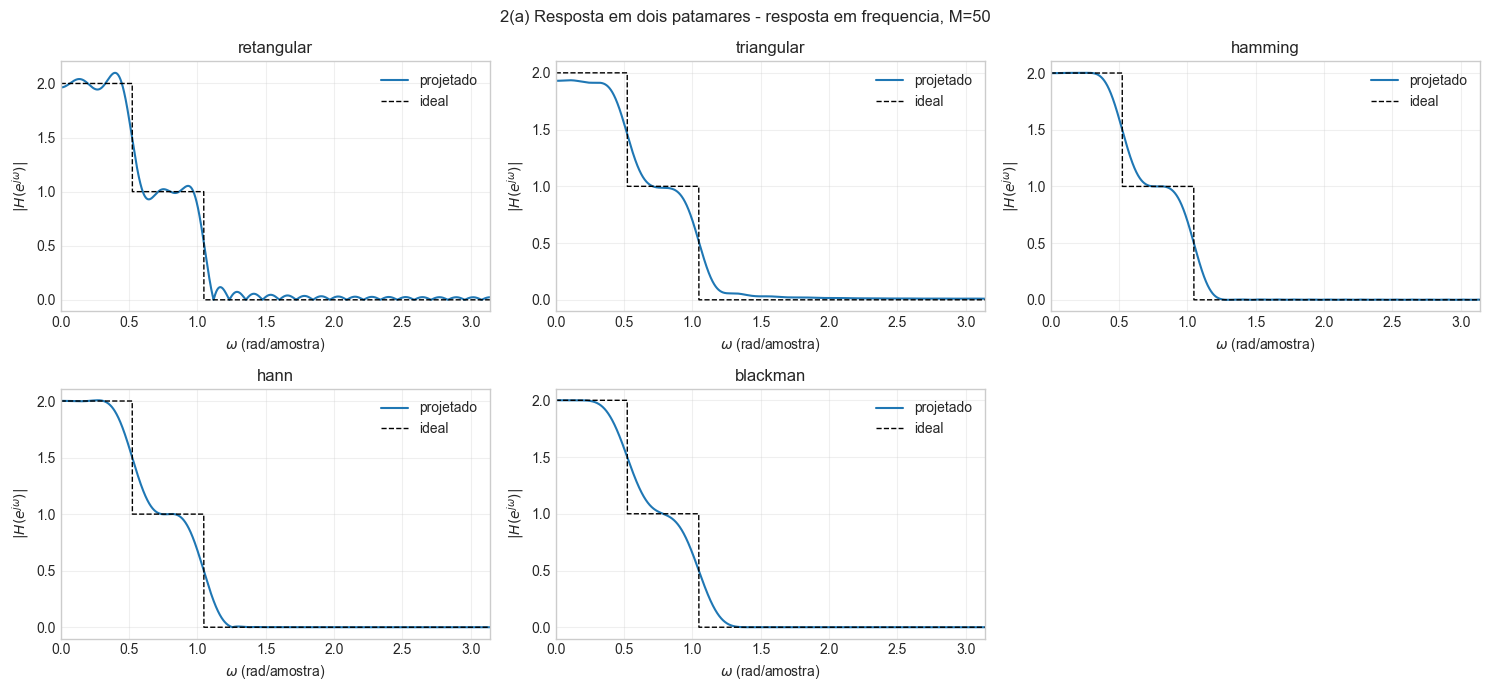

Erros de aproximacao para M=50:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.088945 | 0.530325 | 2.098394 
triangular | 0.125163 | 0.540829 | 1.934852 
hamming    | 0.116320 | 0.501331 | 2.001701 
hann       | 0.120625 | 0.499719 | 2.006684 
blackman   | 0.132418 | 0.499422 | 2.000334 



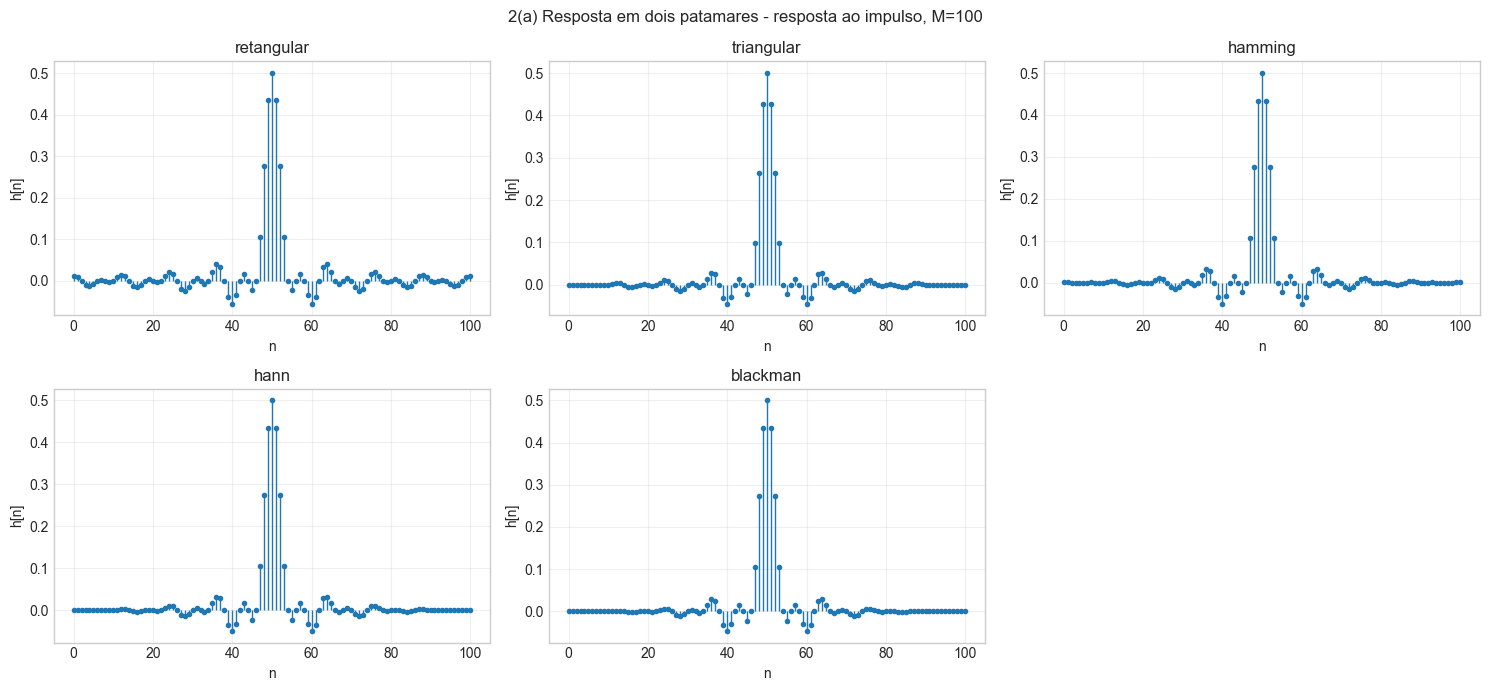

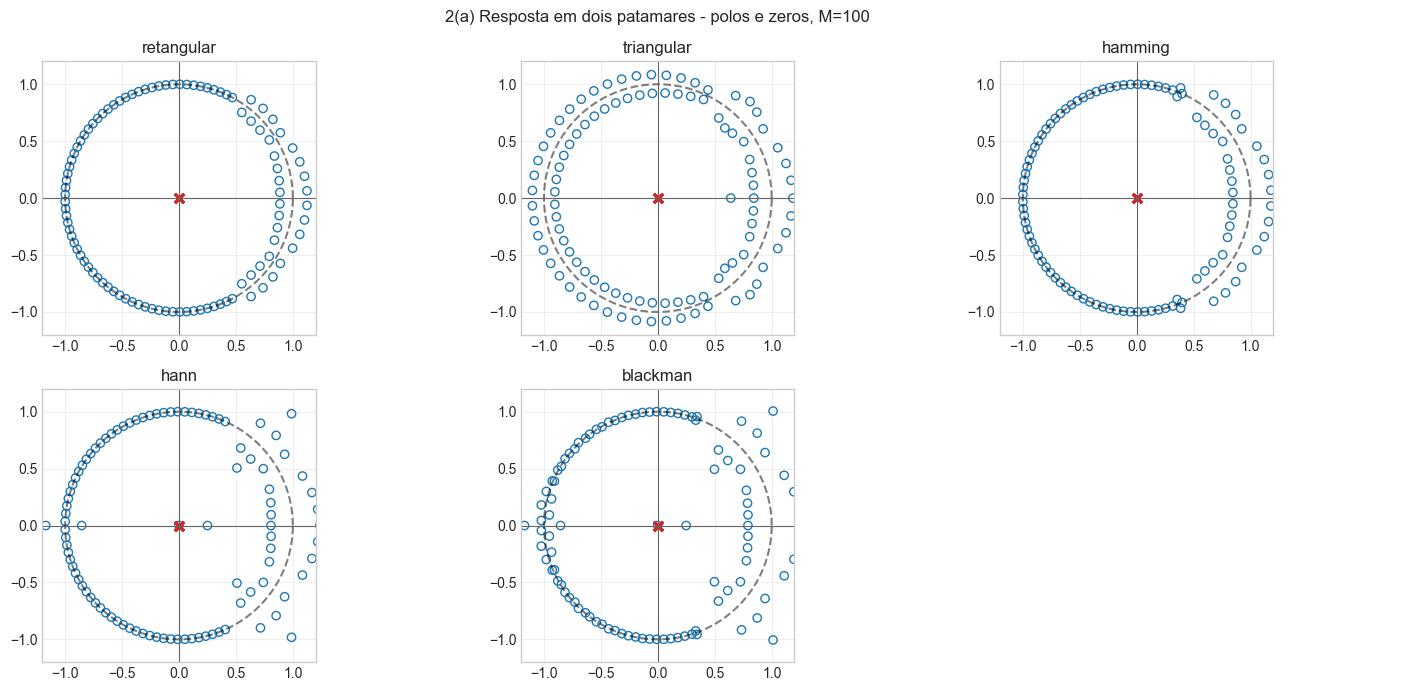

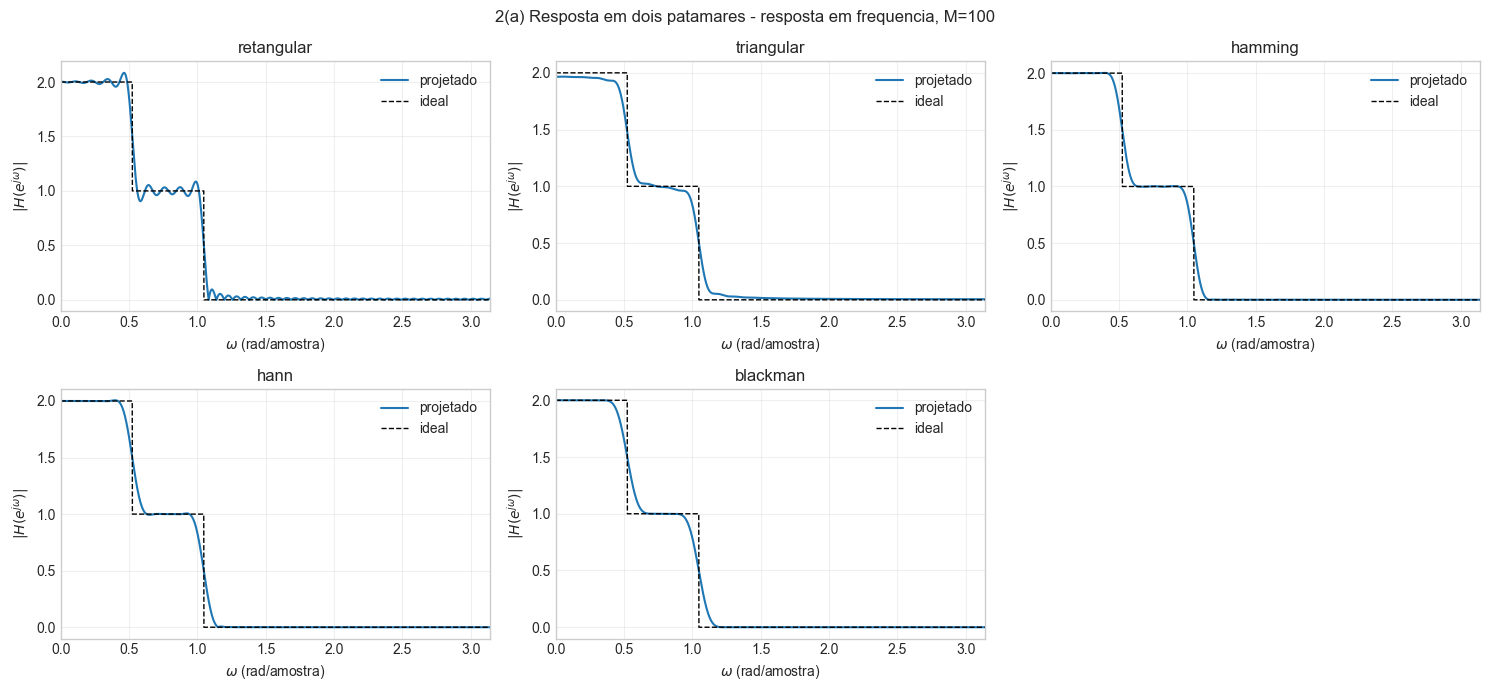

Erros de aproximacao para M=100:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.061891 | 0.502783 | 2.084233 
triangular | 0.089165 | 0.519530 | 1.966495 
hamming    | 0.082145 | 0.499236 | 2.002670 
hann       | 0.085306 | 0.498939 | 2.006367 
blackman   | 0.093641 | 0.499131 | 2.000172 

2(b) Triangulo simetrico


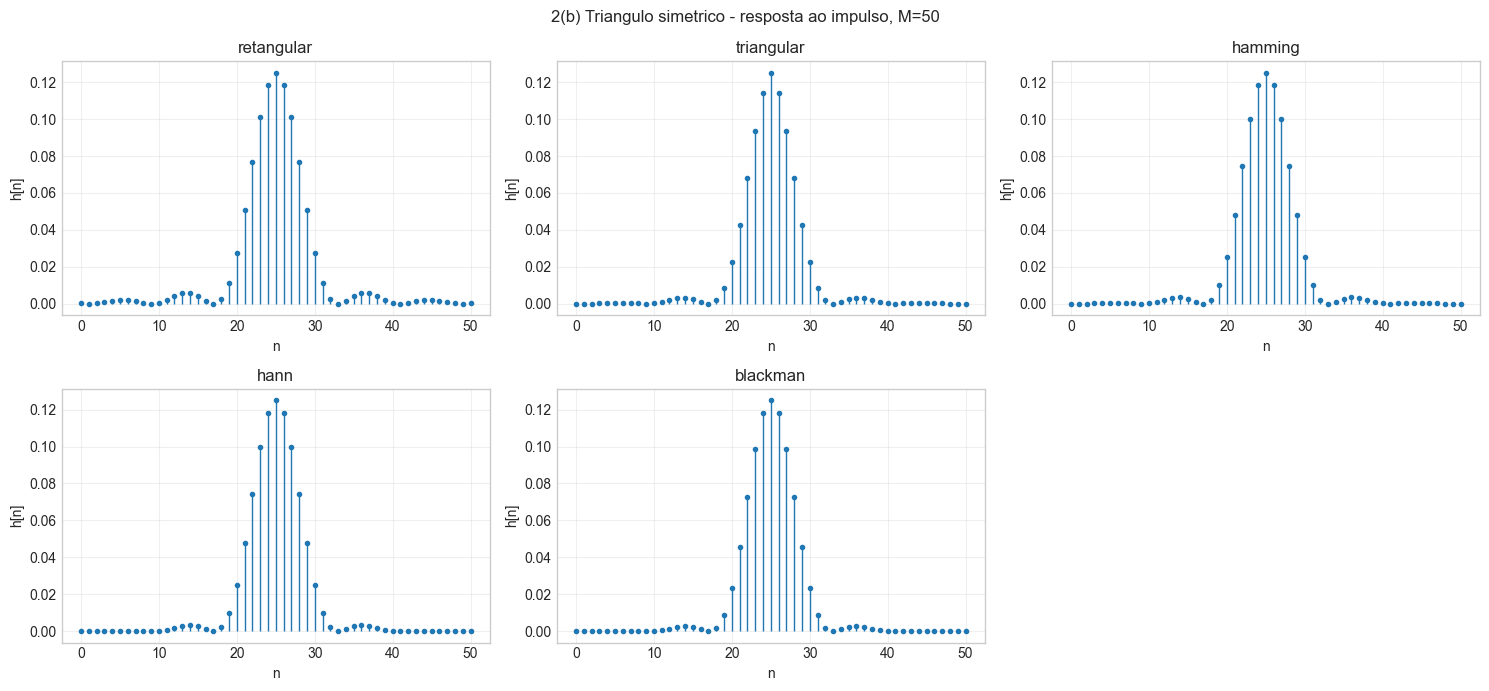

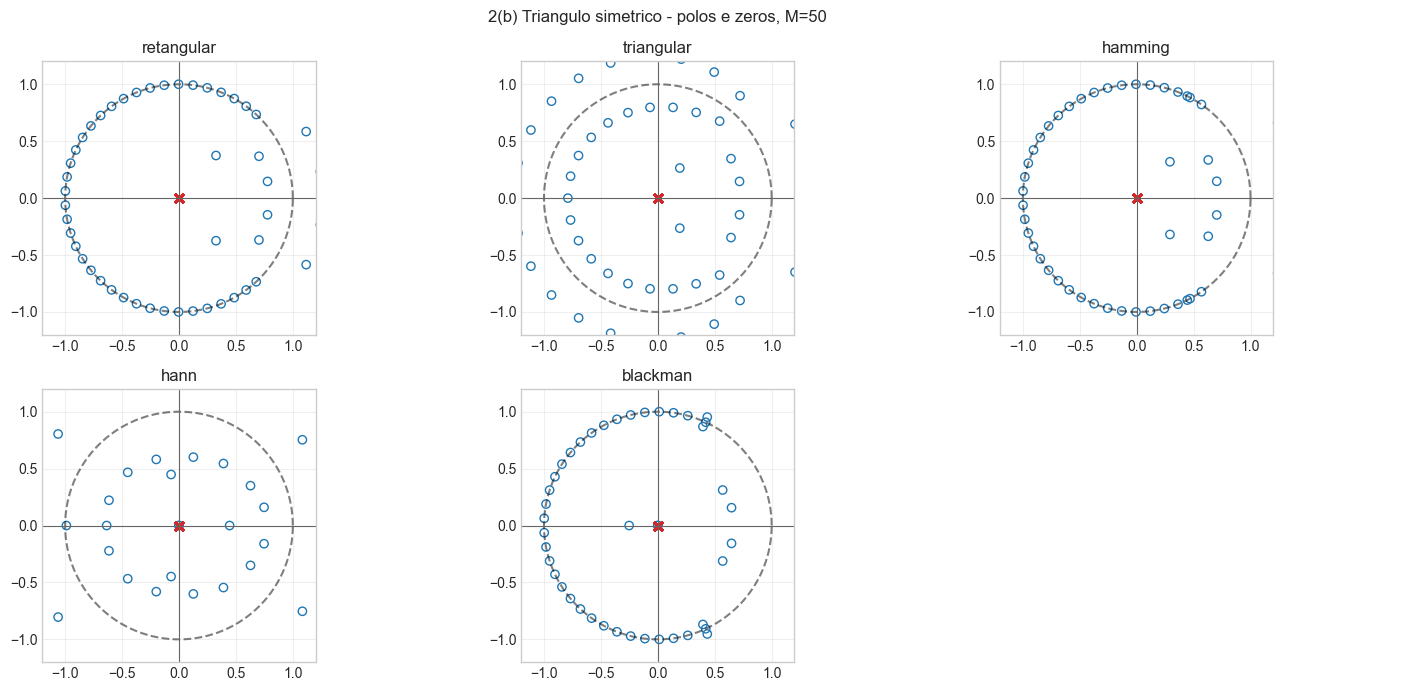

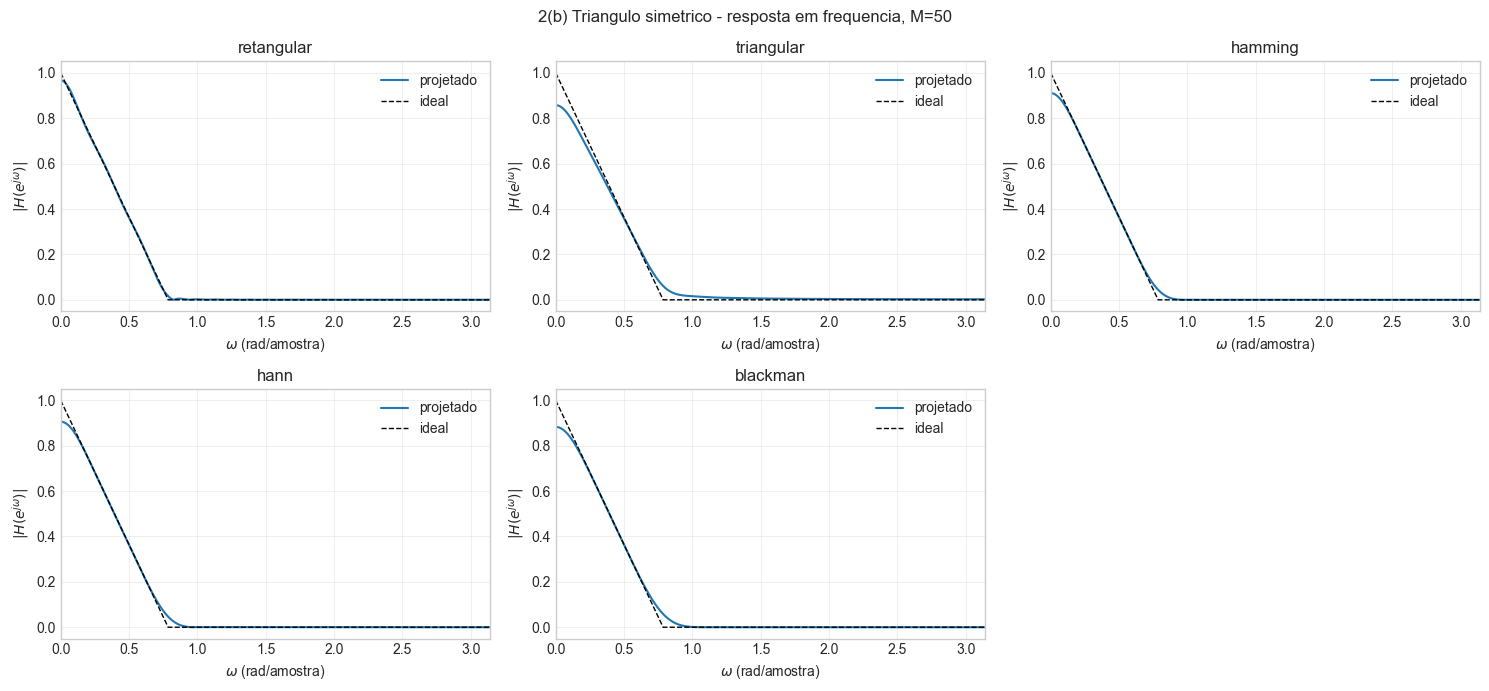

Erros de aproximacao para M=50:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.003379 | 0.033209 | 0.966791 
triangular | 0.024125 | 0.142398 | 0.857602 
hamming    | 0.010678 | 0.089421 | 0.910579 
hann       | 0.011516 | 0.094309 | 0.905691 
blackman   | 0.016145 | 0.117427 | 0.882573 



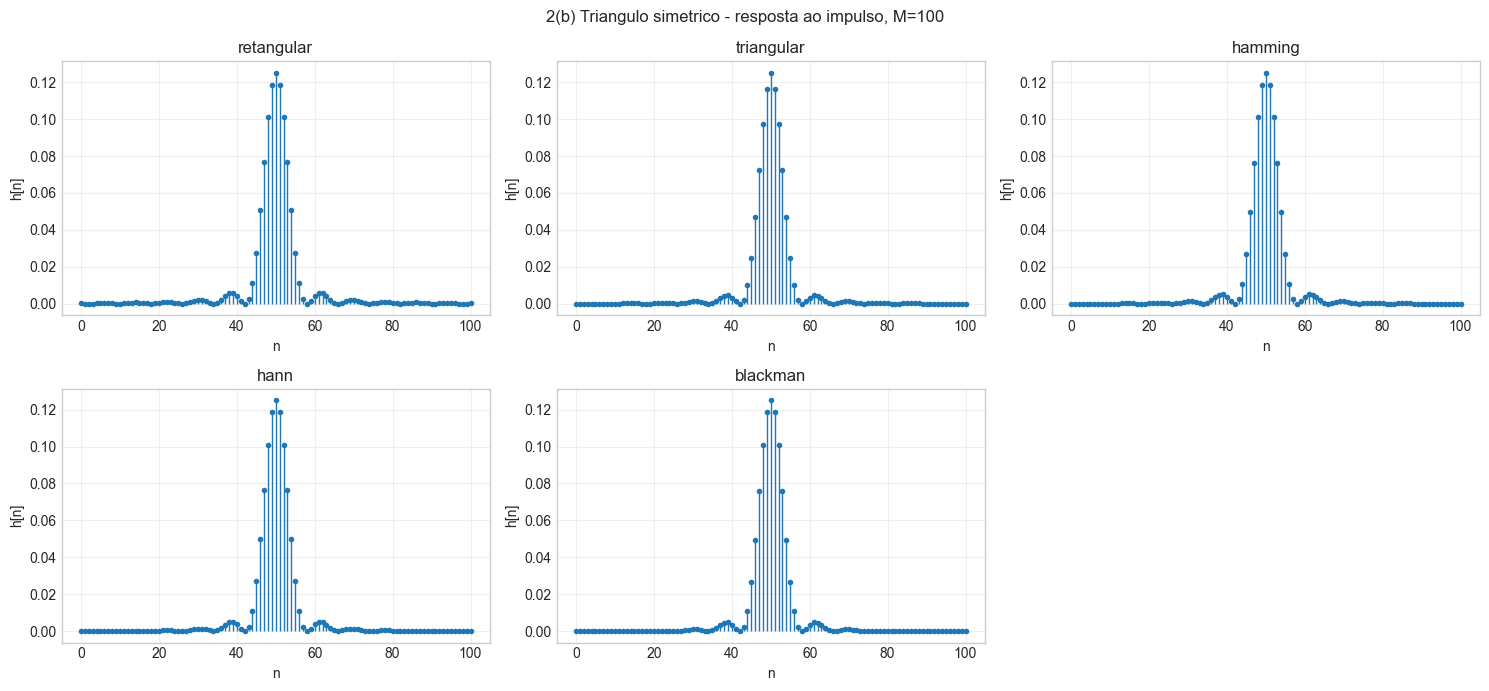

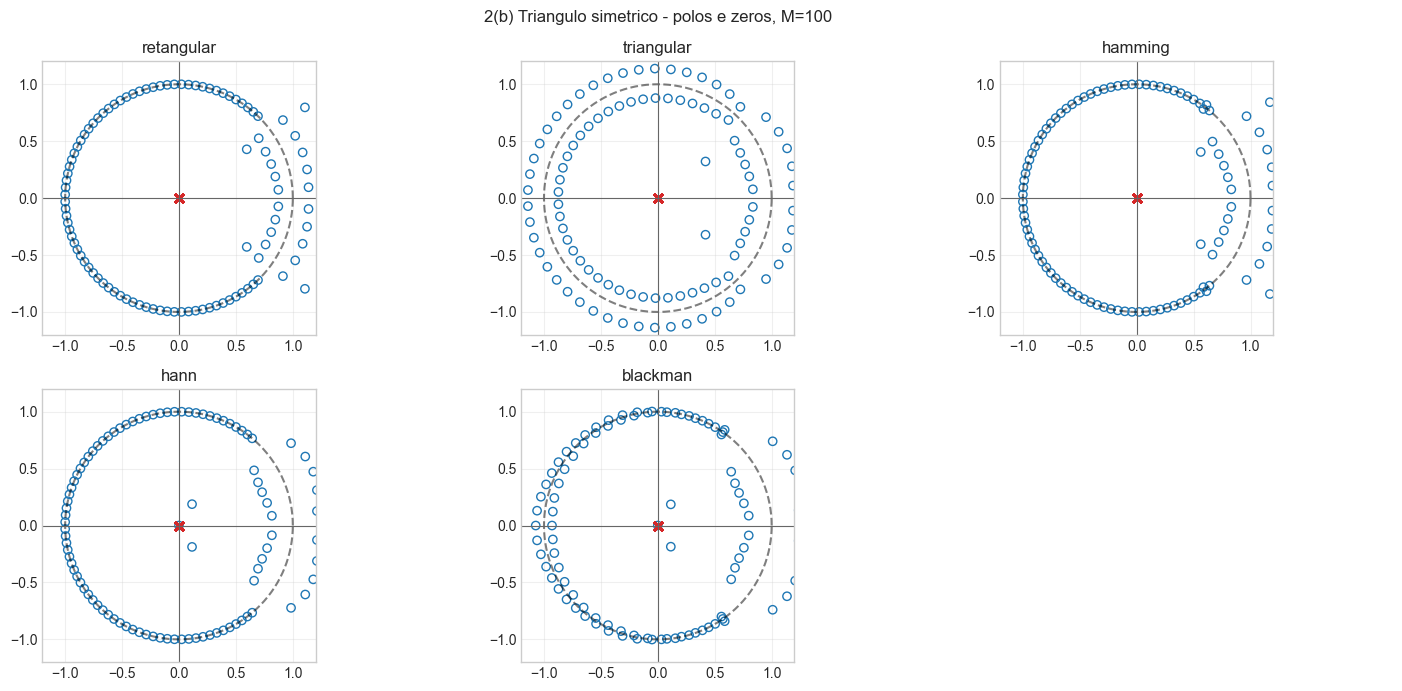

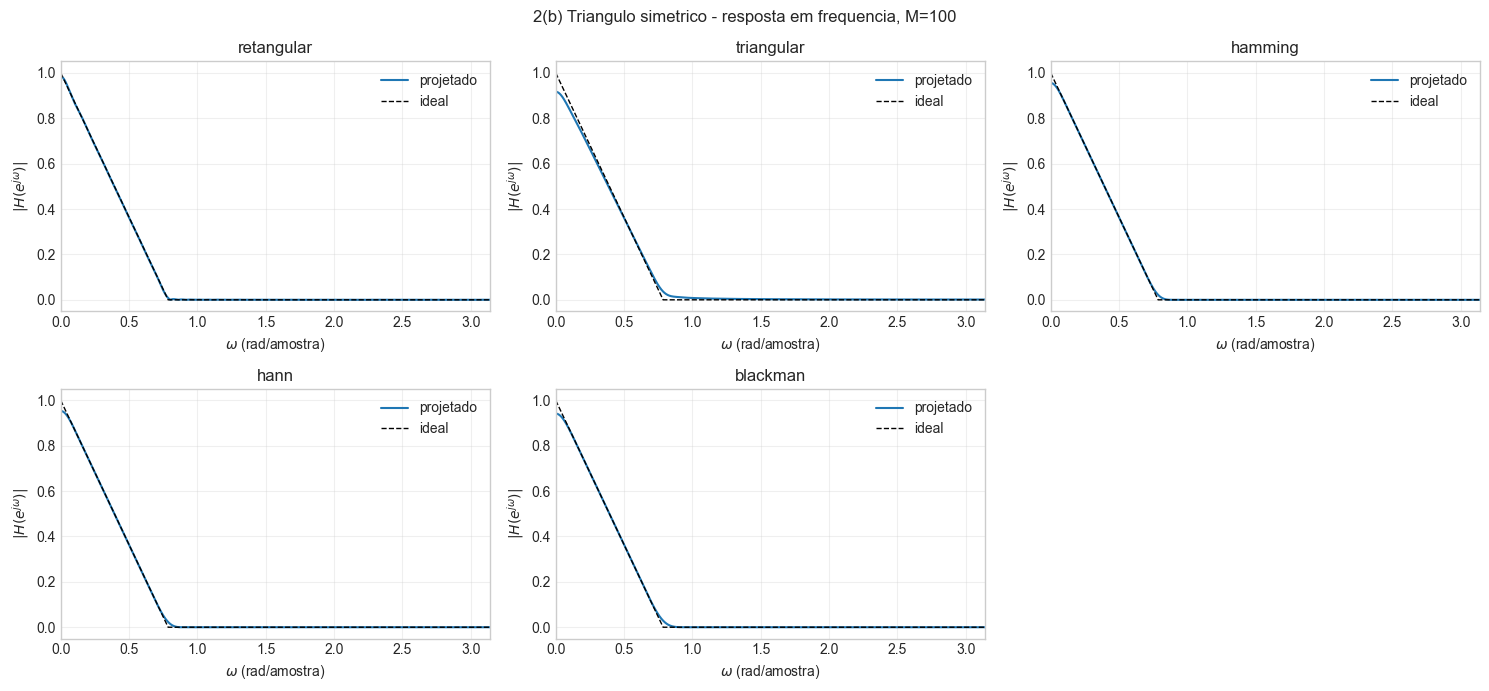

Erros de aproximacao para M=100:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.001195 | 0.016440 | 0.983560 
triangular | 0.012400 | 0.083315 | 0.916685 
hamming    | 0.003783 | 0.044700 | 0.955300 
hann       | 0.004080 | 0.047158 | 0.952842 
blackman   | 0.005717 | 0.058715 | 0.941285 

2(c) Rampa seguida de patamar


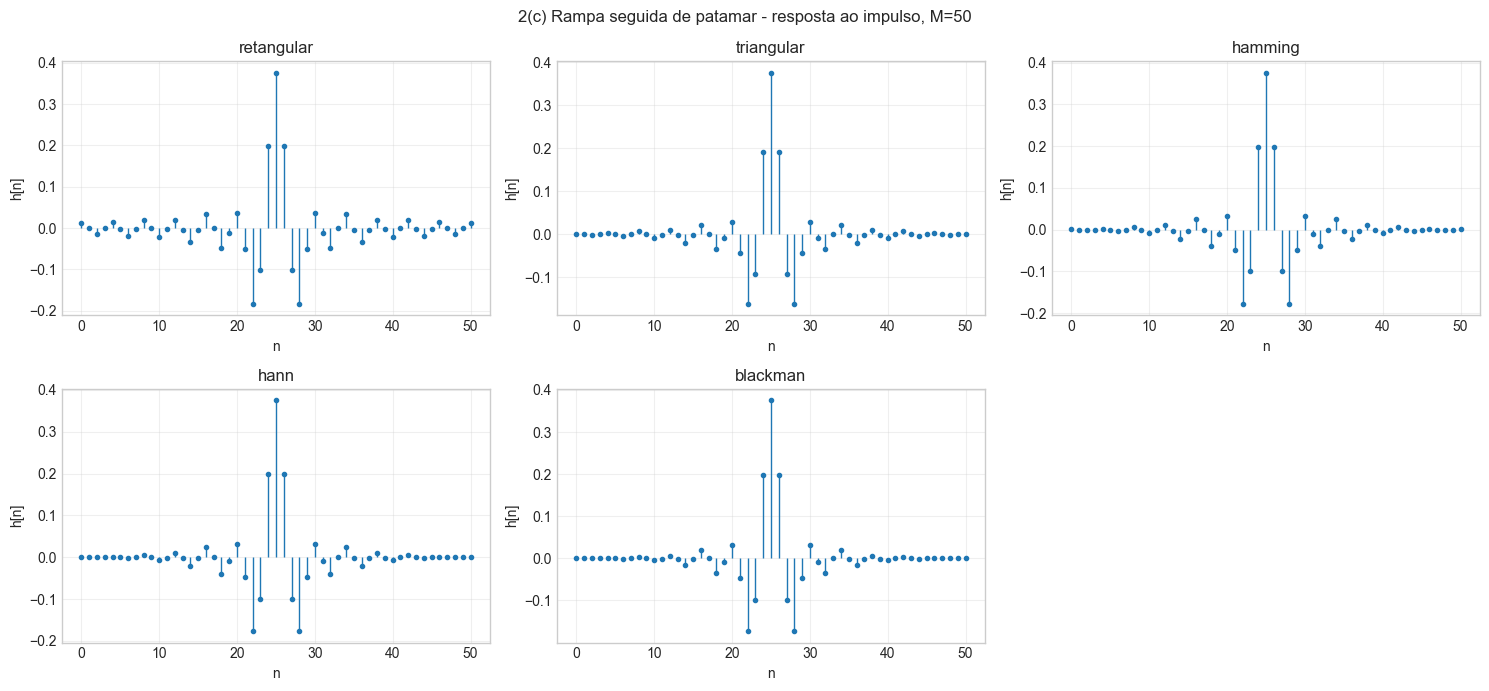

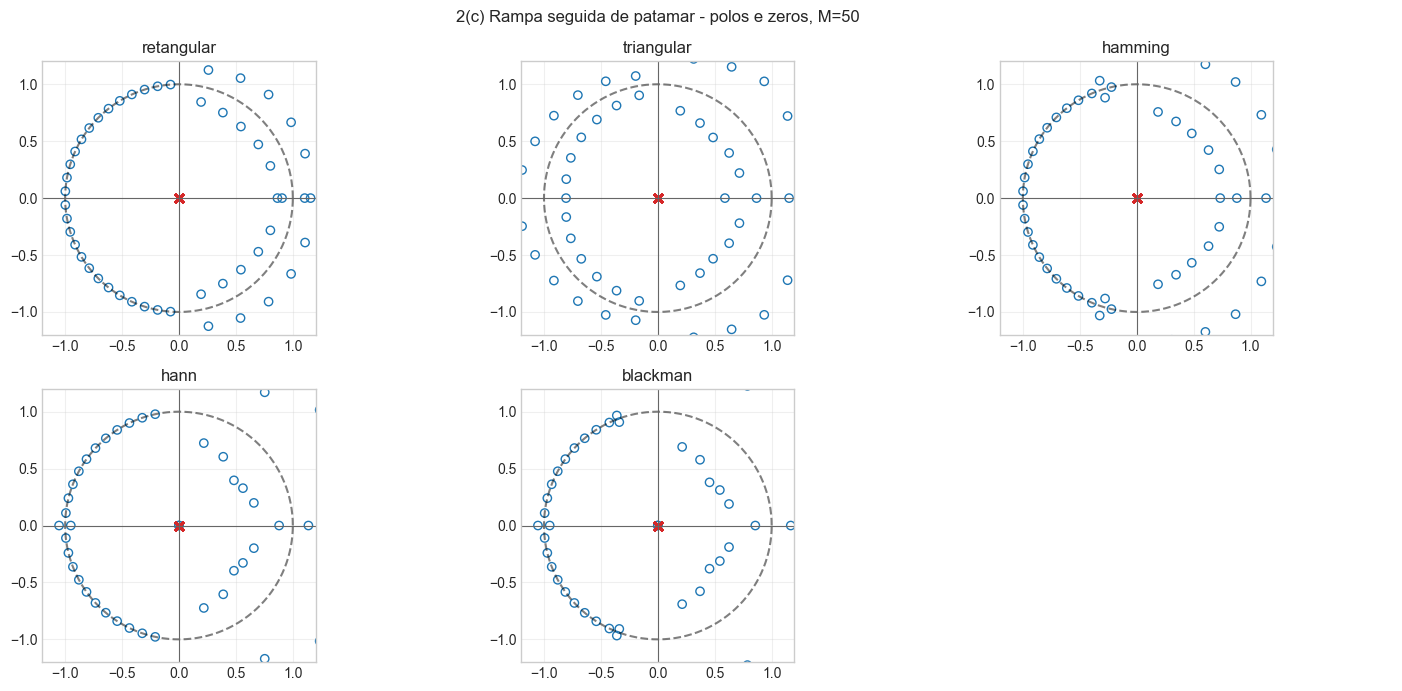

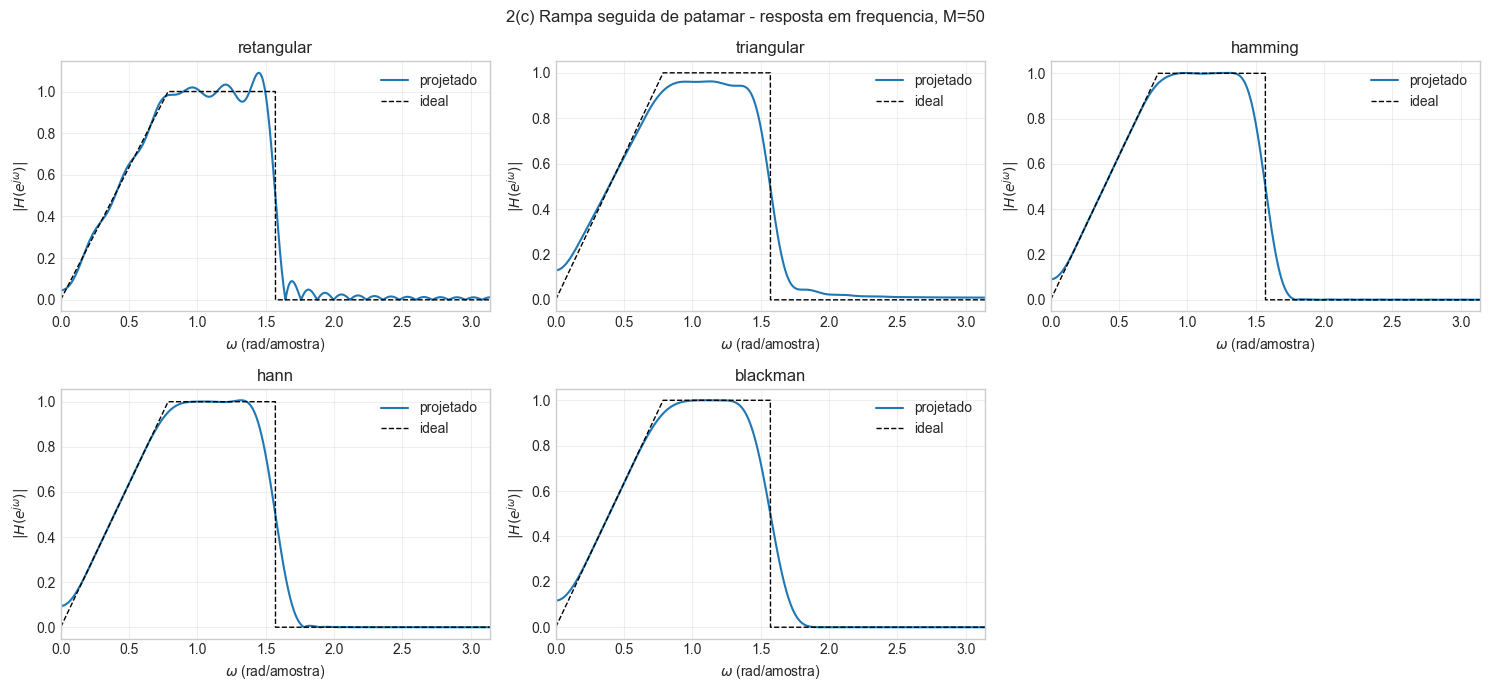

Erros de aproximacao para M=50:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.062637 | 0.500056 | 1.089684 
triangular | 0.091520 | 0.505432 | 0.962429 
hamming    | 0.082902 | 0.500007 | 1.002186 
hann       | 0.086069 | 0.500003 | 1.006343 
blackman   | 0.095019 | 0.500001 | 1.000112 



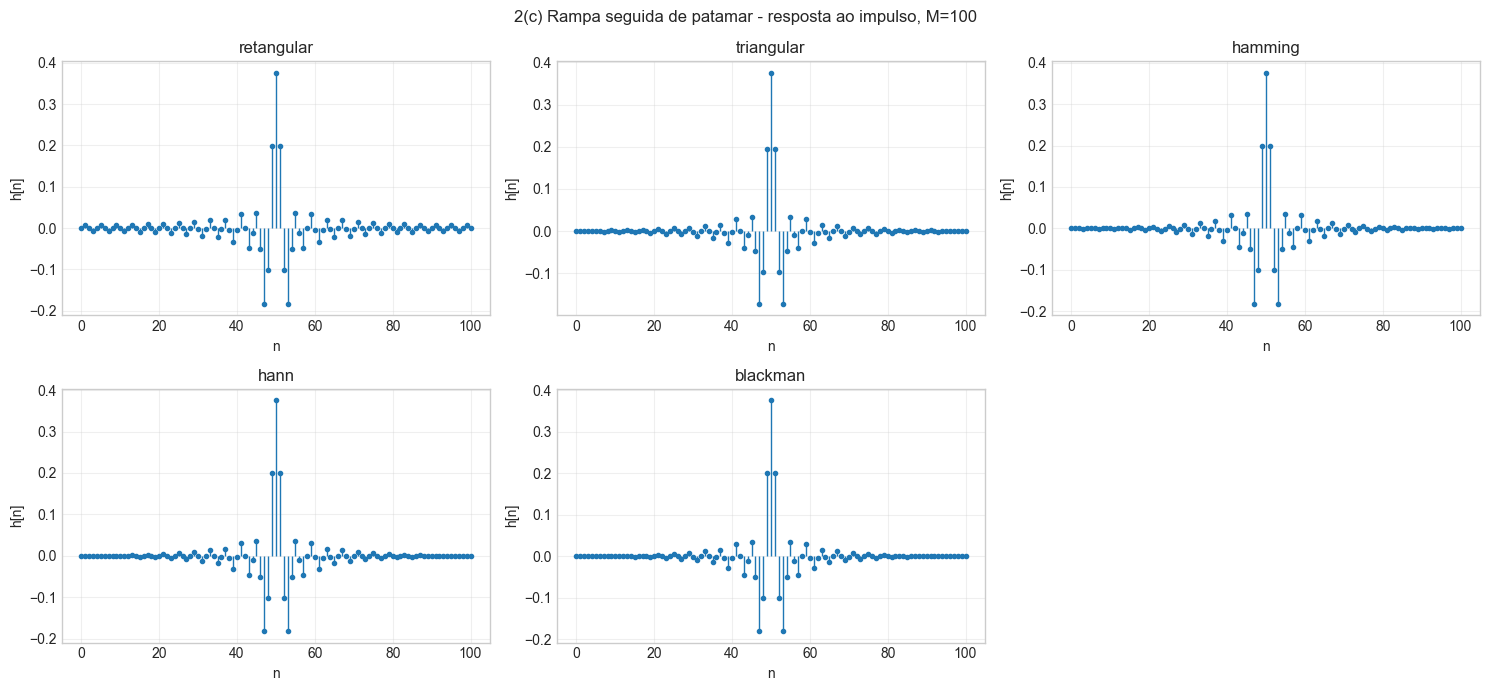

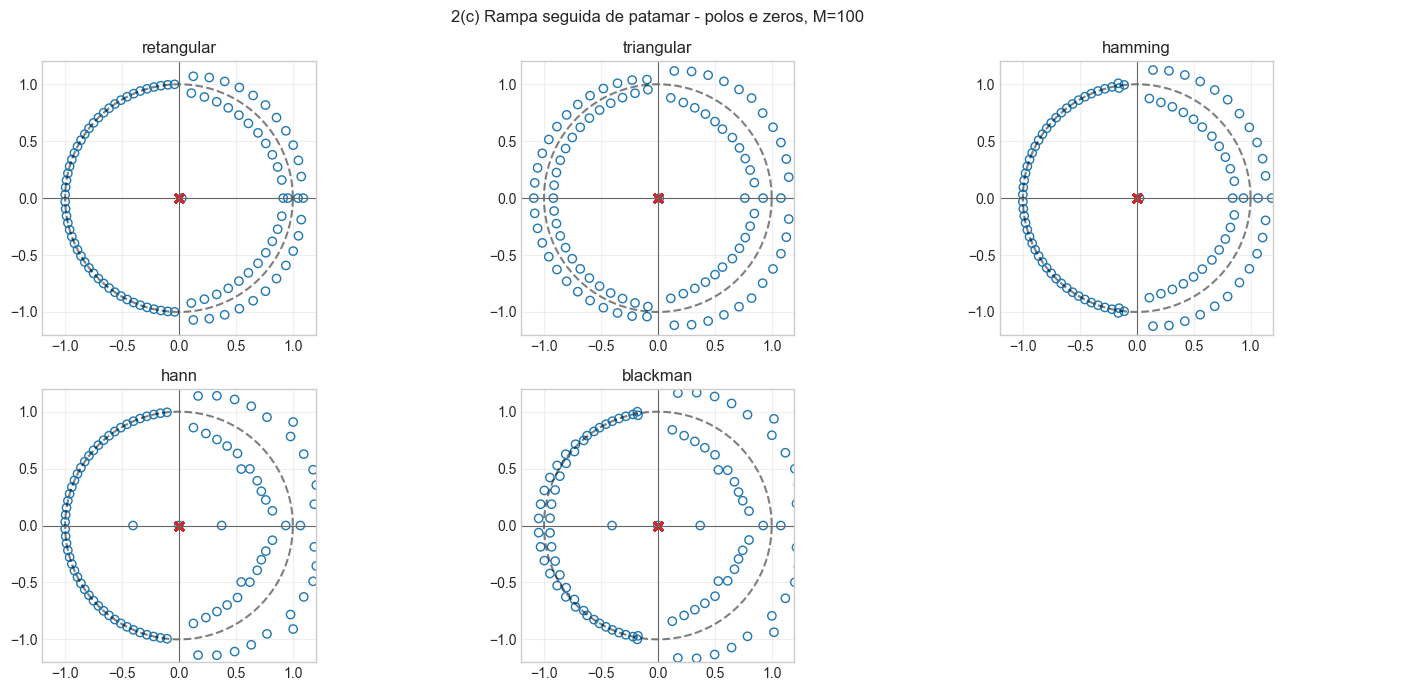

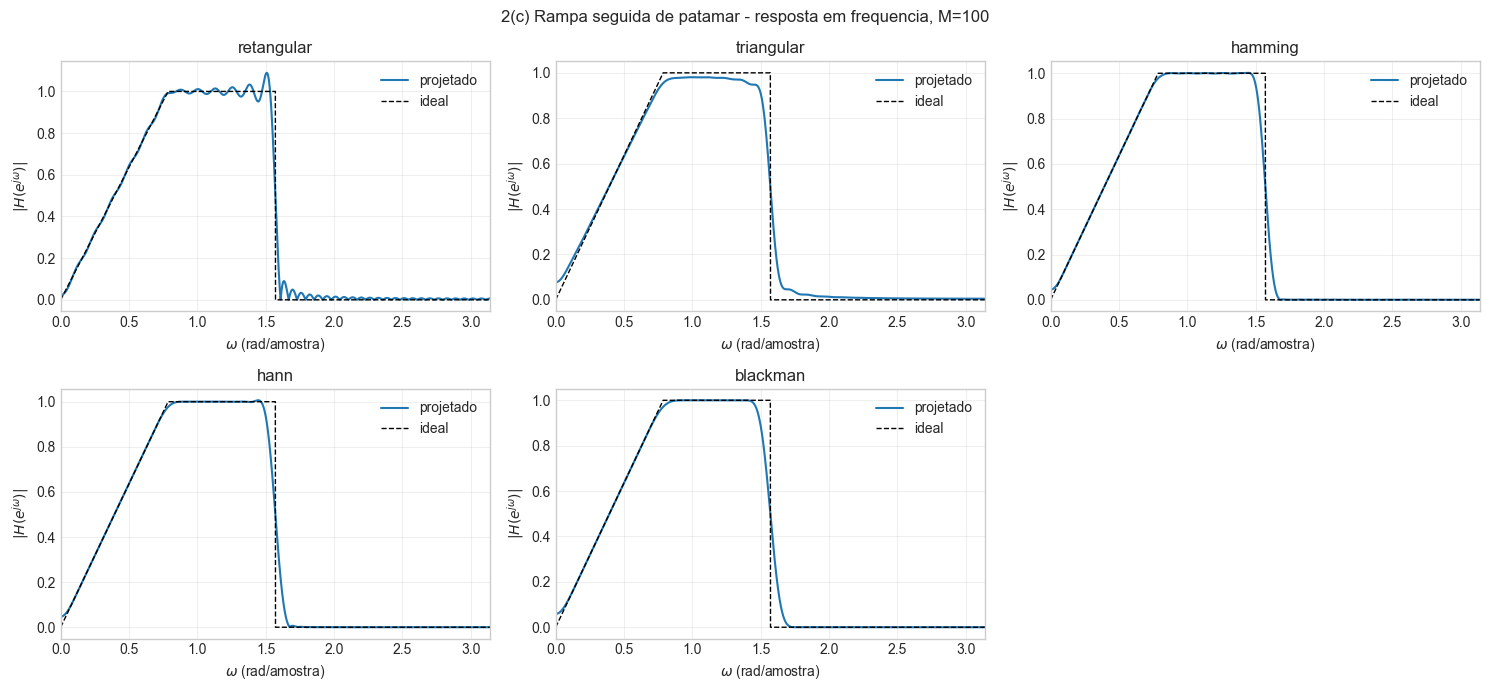

Erros de aproximacao para M=100:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.045055 | 0.499683 | 1.089224 
triangular | 0.064251 | 0.502752 | 0.980758 
hamming    | 0.058352 | 0.499975 | 1.001973 
hann       | 0.060453 | 0.500001 | 1.006351 
blackman   | 0.066459 | 0.500000 | 1.000171 



In [2]:
def q2_case_bank(builder, order):
    return {
        window_name: apply_window(builder(order), window_name, order)
        for window_name in WINDOWS
    }


Q2_CASES = [
    (
        '2(a) Resposta em dois patamares',
        q2a_ideal,
        q2a_magnitude,
    ),
    (
        '2(b) Triangulo simetrico',
        lambda order: q2b_ideal(order, omega_c=OMEGA_C),
        lambda omega: q2b_magnitude(omega, omega_c=OMEGA_C),
    ),
    (
        '2(c) Rampa seguida de patamar',
        q2c_ideal,
        q2c_magnitude,
    ),
]


for title, builder, ideal_mag_fn in Q2_CASES:
    print('=' * 100)
    print(title)
    for order in ORDERS:
        bank = q2_case_bank(builder, order)
        plot_impulse_grid(bank, f'{title} - resposta ao impulso, M={order}', ncols=3, figsize=(15, 7))
        plot_pole_zero_grid(bank, f'{title} - polos e zeros, M={order}', ncols=3, figsize=(15, 7))
        plot_frequency_grid(
            bank,
            f'{title} - resposta em frequencia, M={order}',
            ncols=3,
            figsize=(15, 7),
            xlim=(0.0, np.pi),
            as_db=False,
            ideal_response_fn=ideal_mag_fn,
        )
        rows = summarize_error_bank(bank, ideal_mag_fn, worN=8192, fs_hz=None)
        print(f'Erros de aproximacao para M={order}:')
        display_rows(rows, float_digits=6)
        print()


**Comentarios gerais**

- O item 2(a) pode ser interpretado como a soma de dois passa-baixas ideais; por isso, a resposta ao impulso combina duas componentes do tipo `sinc`.
- O item 2(b) produz uma resposta temporal do tipo `sinc^2`, coerente com um modulo triangular concentrado em baixas frequencias.
- O item 2(c) mistura um trecho de rampa com um patamar, o que gera uma resposta ao impulso com decaimento mais lento do que um simples passa-baixas retangular.
- Em todos os casos, `M = 100` aproxima melhor o ideal do que `M = 50`, enquanto Blackman e Hann reduzem os ripples com o custo de transicoes mais largas.
